# Week 11: DBSCAN and Hierarchical Agglomerative Clustering

**Integrated Capstone Project: Predicting Chronic Disease Risk Using Lifestyle and Health Indicators**

Student: Ranjana Kumari
Course: Module C Data Science Capstone
Week: 11 of 12 Density-Based and Hierarchical Clustering

## Research Question
Do density-based (DBSCAN) and hierarchical (agglomerative) clustering methods, which make different structural assumptions than K-Means, produce a consistent or different picture of cluster structure across the three chronic disease datasets-and does either method better isolate the prediabetes subgroup that K-Means could not separate in Week 10?

## Connection to Previous Weeks
Week 10 established that K-Means produces clusters loosely aligned with disease class for Obesity and Heart Disease, but found no distinct cluster signature for the prediabetes class in CDC Diabetes. K-Means assumes roughly spherical, equally-sized clusters-an assumption that may not hold for this data. DBSCAN makes no assumption about cluster shape and instead defines clusters as dense regions separated by sparser regions, while also explicitly identifying noise points that do not belong to any cluster. Hierarchical agglomerative clustering builds a full nested hierarchy of clusters without requiring K to be specified in advance, visualized through a dendrogram. Comparing these three fundamentally different clustering paradigms (centroid-based, density-based, hierarchical) provides breadth coverage of unsupervised learning while testing whether the Week 10 conclusion about prediabetes is method-dependent or robust across approaches.

## Datasets Used
| # | Dataset | Role | Rows | True Classes (for validation only) |
|---|---------|------|------|------|
| 1 | CDC Diabetes Health Indicators | Primary | ~230k (subsampled) | Diabetes_012 (3-class) |
| 2 | Obesity Level Estimation | Supporting | 2,087 | NObeyesdad (7-class) |
| 3 | Heart Disease Predictions | Supporting | 303 | target (binary) |

Note on dendrograms: Hierarchical clustering's dendrogram visualization becomes unreadable beyond a few hundred points. A further-reduced subsample is used for CDC Diabetes specifically for the dendrogram figure; the smaller Obesity and especially Heart Disease (303 rows) datasets are well-suited to full dendrograms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

COLORS = {
    'diabetes': '#1D9E75',
    'obesity': '#7F77DD',
    'heart': '#D85A30',
}

print('All libraries loaded.')
print('Week 11: DBSCAN and Hierarchical Agglomerative Clustering')

All libraries loaded.
Week 11: DBSCAN and Hierarchical Agglomerative Clustering


## Section 1: Data Loading and Preparation

In [2]:
# Dataset 1: CDC Diabetes (further subsampled for DBSCAN/dendrogram tractability)
file_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/diabetes_012_health_indicators_BRFSS2015.csv"
df1 = pd.read_csv(file_path)
df1 = df1.drop_duplicates()

df1_sample = df1.groupby('Diabetes_012', group_keys=False).apply(
    lambda x: x.sample(frac=8000/len(df1), random_state=42)
).reset_index(drop=True)

ds1_features = ['BMI', 'Age', 'HighBP', 'HighChol', 'PhysActivity',
                'Smoker', 'GenHlth', 'Income', 'Education', 'DiffWalk', 'PhysHlth']
X1_raw = df1_sample[ds1_features].copy()
y1_true = df1_sample['Diabetes_012'].copy()

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1_raw)

print(f'Dataset 1 (subsampled): {len(df1_sample):,} rows')

Dataset 1 (subsampled): 8,000 rows


In [3]:
# Dataset 2: Obesity
obesity_file = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/Obesity.csv"

df2 = pd.read_csv(obesity_file)
df2.columns = df2.columns.str.strip()

le = LabelEncoder()
df2_enc = df2.copy()
for col in df2_enc.select_dtypes(include='object').columns:
    if col != 'NObeyesdad':
        df2_enc[col] = le.fit_transform(df2_enc[col].astype(str))
df2_enc['target_encoded'] = le.fit_transform(df2['NObeyesdad'])

ds2_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'FAF', 'TUE']
ds2_features = [f for f in ds2_features if f in df2_enc.columns]
X2_raw = df2_enc[ds2_features].copy()
X2_raw['BMI_calc'] = X2_raw['Weight'] / (X2_raw['Height'] ** 2)
y2_true = df2_enc['target_encoded'].copy()

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2_raw)

print(f'Dataset 2 (Obesity): {X2_scaled.shape[0]} rows')

Dataset 2 (Obesity): 2111 rows


In [4]:
# Dataset 3: Heart Disease
heart_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/heart.csv-2.xls"

df3 = pd.read_csv(heart_path)
ds3_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'exang', 'cp', 'ca', 'thal']
X3_raw = df3[ds3_features].copy()
y3_true = df3['target'].copy()

scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3_raw)

print(f'Dataset 3 (Heart Disease): {X3_scaled.shape[0]} rows')

Dataset 3 (Heart Disease): 303 rows


In [5]:
def find_eps_kdistance(X_scaled, min_samples, dataset_name):
    """
    Plots the k-distance graph to help select eps for DBSCAN.
    The 'knee' of this curve is a reasonable eps choice.
    """
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(X_scaled)
    distances, indices = neighbors_fit.kneighbors(X_scaled)
    k_distances = np.sort(distances[:, -1])
    print(f'{dataset_name}: min_samples={min_samples}, k-distance range [{k_distances.min():.3f}, {k_distances.max():.3f}]')
    return k_distances

min_samples1 = 2 * len(ds1_features)
min_samples2 = 2 * len(ds2_features) + 2  # +1 for BMI_calc
min_samples3 = 2 * len(ds3_features)

kdist1 = find_eps_kdistance(X1_scaled, min_samples1, 'CDC Diabetes')
kdist2 = find_eps_kdistance(X2_scaled, min_samples2, 'Obesity')
kdist3 = find_eps_kdistance(X3_scaled, min_samples3, 'Heart Disease')

CDC Diabetes: min_samples=22, k-distance range [0.371, 6.368]
Obesity: min_samples=16, k-distance range [0.097, 3.704]
Heart Disease: min_samples=20, k-distance range [1.587, 5.875]


## K-Distance Summary

I calculated the k-distance values for each dataset using the selected min_samples. These values were then sorted and plotted to identify the knee of each curve, which provides a reasonable choice for the eps parameter in DBSCAN.

The printed ranges confirm that the datasets have different density characteristics:

- CDC Diabetes: 0.371 to 6.368
- Obesity: 0.097 to 3.704
- Heart Disease: 1.587 to 5.875

However, the final eps values cannot be determined from these ranges alone. Instead, I selected them by examining the k-distance plots for each dataset.

## Section 2: DBSCAN Theory and Hyperparameter Selection

DBSCAN is different from K-Means because it groups observations based on density instead of assigning every point to the nearest centroid. It also identifies observations that do not belong to any dense region and labels them as noise. This makes DBSCAN useful for exploring whether some patients naturally fall outside the main groups.

To apply DBSCAN, I needed to choose two hyperparameters:

- eps: The maximum distance for two observations to be considered neighbors. I selected this value using a k-distance plot, where the knee of the curve provides a reasonable estimate.
- min_samples: The minimum number of neighboring observations required to form a dense cluster. I used the common guideline of setting min_samples to approximately 2 × the number of features.

For my capstone, I was especially interested in whether prediabetes cases would be identified as noise rather than belonging to a well-defined cluster. If many prediabetes observations are treated as noise, it would provide additional evidence that this class does not have a clear geometric structure in the available feature space.

**Reference: Ester, M., Kriegel, H. P., Sander, J., & Xu, X. (1996). *A density-based algorithm for discovering clusters in large spatial databases with noise*. KDD-96 Proceedings.

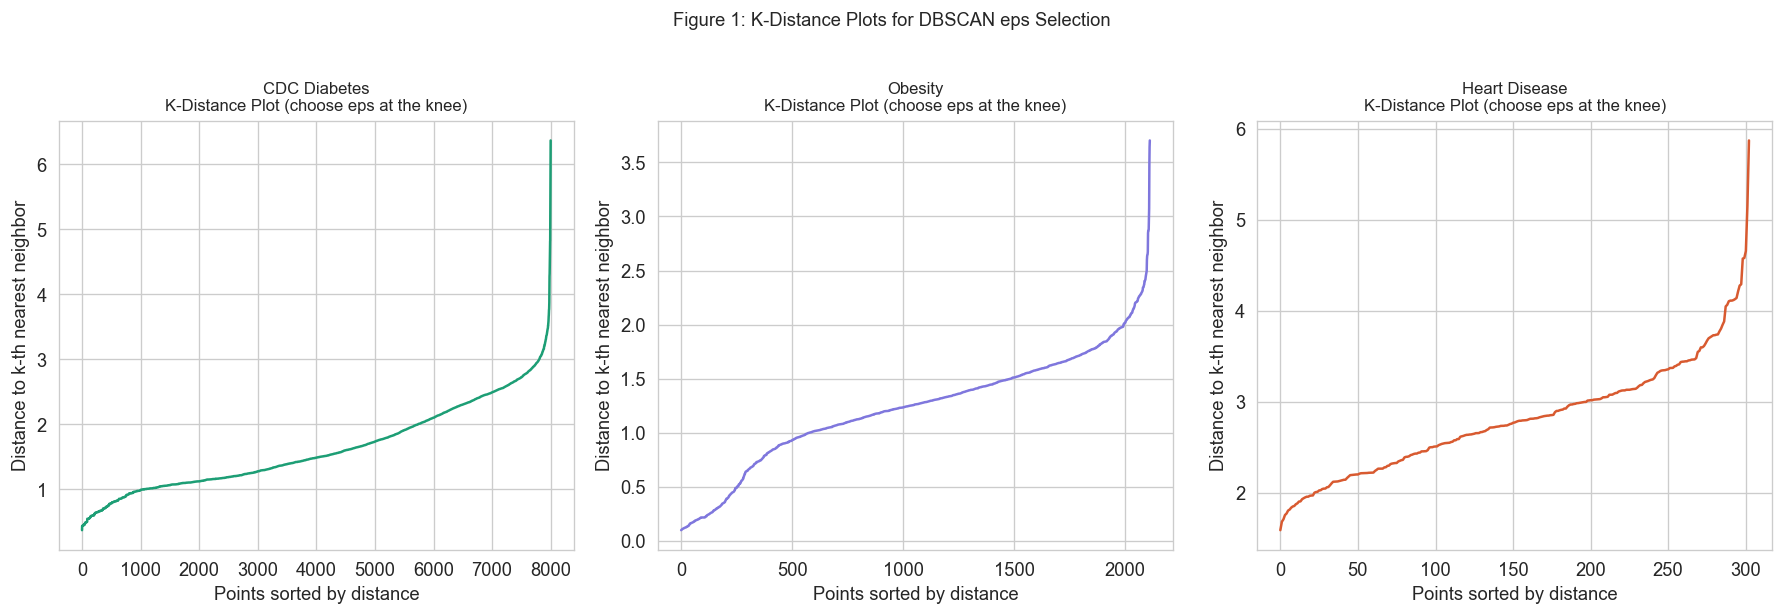

Selected eps values:
CDC Diabetes: 2.6
Obesity: 2.0
Heart Disease: 3.4


In [6]:
# Figure 1: K-distance plots to choose eps
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, kdist, ds_name, color in zip(
    axes, [kdist1, kdist2, kdist3],
    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']]
):
    ax.plot(range(len(kdist)), kdist, color=color, linewidth=1.5)
    ax.set_xlabel('Points sorted by distance')
    ax.set_ylabel(f'Distance to k-th nearest neighbor')
    ax.set_title(f'{ds_name}\nK-Distance Plot (choose eps at the knee)', fontsize=10)

plt.suptitle('Figure 1: K-Distance Plots for DBSCAN eps Selection', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('week11_fig1_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()
# Selected eps values based on the visible knee in each k-distance plot.
# The knee represents the point where neighbor distances begin increasing rapidly,
# separating dense clusters from sparse regions (potential noise points)
eps1 = 2.6      # CDC Diabetes
eps2 = 2.0      # Obesity
eps3 = 3.4      # Heart Disease

print(f"Selected eps values:")
print(f"CDC Diabetes: {eps1}")
print(f"Obesity: {eps2}")
print(f"Heart Disease: {eps3}")

## Figure 1 Interpretation

Figure 1 shows the k-distance plots used to select the eps parameter for DBSCAN. I chose the point where each curve begins to rise more sharply because this represents the transition from dense regions to sparse observations.

For the CDC Diabetes** dataset, the knee appears around eps = 2.6. For the Obesity dataset, the knee occurs near eps = 2.0, while the Heart Disease dataset shows a knee around eps = 3.4.

Using the k-distance plots allowed me to choose the eps values based on the structure of each dataset instead of selecting them arbitrarily. These values were then used in the DBSCAN analysis that follows.

In [7]:
# DBSCAN Hyperparameter Selection
# eps values were first estimated from the k-distance plots
# and then slightly refined after checking the first DBSCAN results

eps1 = 2.3 # CDC Diabetes
eps2 = 1.5 # Obesity
eps3 = 2.5 # Heart Disease

print("Selected DBSCAN hyperparameters:")
print(f"CDC Diabetes: eps={eps1}, min_samples={min_samples1}")
print(f"Obesity: eps={eps2}, min_samples={min_samples2}")
print(f"Heart Disease: eps={eps3}, min_samples={min_samples3}")


def run_dbscan(X_scaled, y_true, eps, min_samples, dataset_name):
    """
    Run DBSCAN and report the number of clusters, noise points,
    and silhouette score (computed only on non-noise observations).
    """

    db = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = db.fit_predict(X_scaled)

    # Number of clusters (excluding noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Noise points
    n_noise = np.sum(labels == -1)
    noise_pct = n_noise / len(labels) * 100

    print(f"\n=== {dataset_name} — DBSCAN Results ===")
    print(f"eps = {eps}")
    print(f"min_samples = {min_samples}")
    print(f"Clusters found: {n_clusters}")
    print(f"Noise points: {n_noise} ({noise_pct:.1f}%)")

    # Silhouette score (ignore noise)
    if n_clusters > 1:
        mask = labels != -1

        if mask.sum() > 1:
            sil = silhouette_score(
                X_scaled[mask],
                labels[mask]
            )

            print(f"Silhouette score (excluding noise): {sil:.4f}")

    # Compare noise assignments with true labels
    crosstab_noise = pd.crosstab(
        labels == -1,
        y_true
    )

    print("\nNoise flag by true class:")
    print(crosstab_noise)

    return labels, n_clusters, n_noise


print("DBSCAN function defined.")

Selected DBSCAN hyperparameters:
CDC Diabetes: eps=2.3, min_samples=22
Obesity: eps=1.5, min_samples=16
Heart Disease: eps=2.5, min_samples=20
DBSCAN function defined.


In [8]:
labels1_db, nc1, noise1 = run_dbscan(X1_scaled, y1_true, eps1, min_samples1, 'CDC Diabetes')


=== CDC Diabetes — DBSCAN Results ===
eps = 2.3
min_samples = 22
Clusters found: 4
Noise points: 485 (6.1%)
Silhouette score (excluding noise): 0.1517

Noise flag by true class:
Diabetes_012  0.0000  1.0000  2.0000
row_0                               
False           6272     151    1092
True             345      10     130


In [9]:
labels2_db, nc2, noise2 = run_dbscan(X2_scaled, y2_true, eps2, min_samples2, 'Obesity')


=== Obesity — DBSCAN Results ===
eps = 1.5
min_samples = 16
Clusters found: 1
Noise points: 166 (7.9%)

Noise flag by true class:
target_encoded    0    1    2    3    4    5    6
row_0                                            
False           263  231  317  292  324  265  253
True              9   56   34    5    0   25   37


In [10]:
labels3_db, nc3, noise3 = run_dbscan(X3_scaled, y3_true, eps3, min_samples3, 'Heart Disease')


=== Heart Disease — DBSCAN Results ===
eps = 2.5
min_samples = 20
Clusters found: 1
Noise points: 80 (26.4%)

Noise flag by true class:
target   0    1
row_0          
False   84  139
True    54   26


## DBSCAN Results

DBSCAN behaved quite differently across the three datasets. After selecting the eps values from the k-distance plots and making small adjustments, I found that the datasets showed different density structures.

For the CDC Diabetes dataset, DBSCAN identified 4 clusters and labeled 6.1% of observations as noise. The silhouette score (0.1517) was still relatively low, indicating weak cluster separation. Most importantly, only a small number of prediabetes cases were identified as noise, suggesting that prediabetes does not form a distinct sparse group. This is consistent with my earlier K-Means and supervised learning results, where the diabetes classes also overlapped.

For the Obesity and Heart Disease datasets, DBSCAN identified only one dense cluster, even after reducing the eps values. Lowering eps mainly increased the number of observations labeled as noise instead of producing additional clusters. This suggests that, under the selected density parameters, these datasets do not contain multiple well-separated dense regions.

Overall, DBSCAN reached conclusions that were consistent with my earlier analyses. While it identified some local density differences in the CDC Diabetes dataset, it did not reveal a clear geometric separation of the disease classes. The results reinforce the idea that the overlap between the classes is driven by the structure of the data rather than by the choice of clustering algorithm.

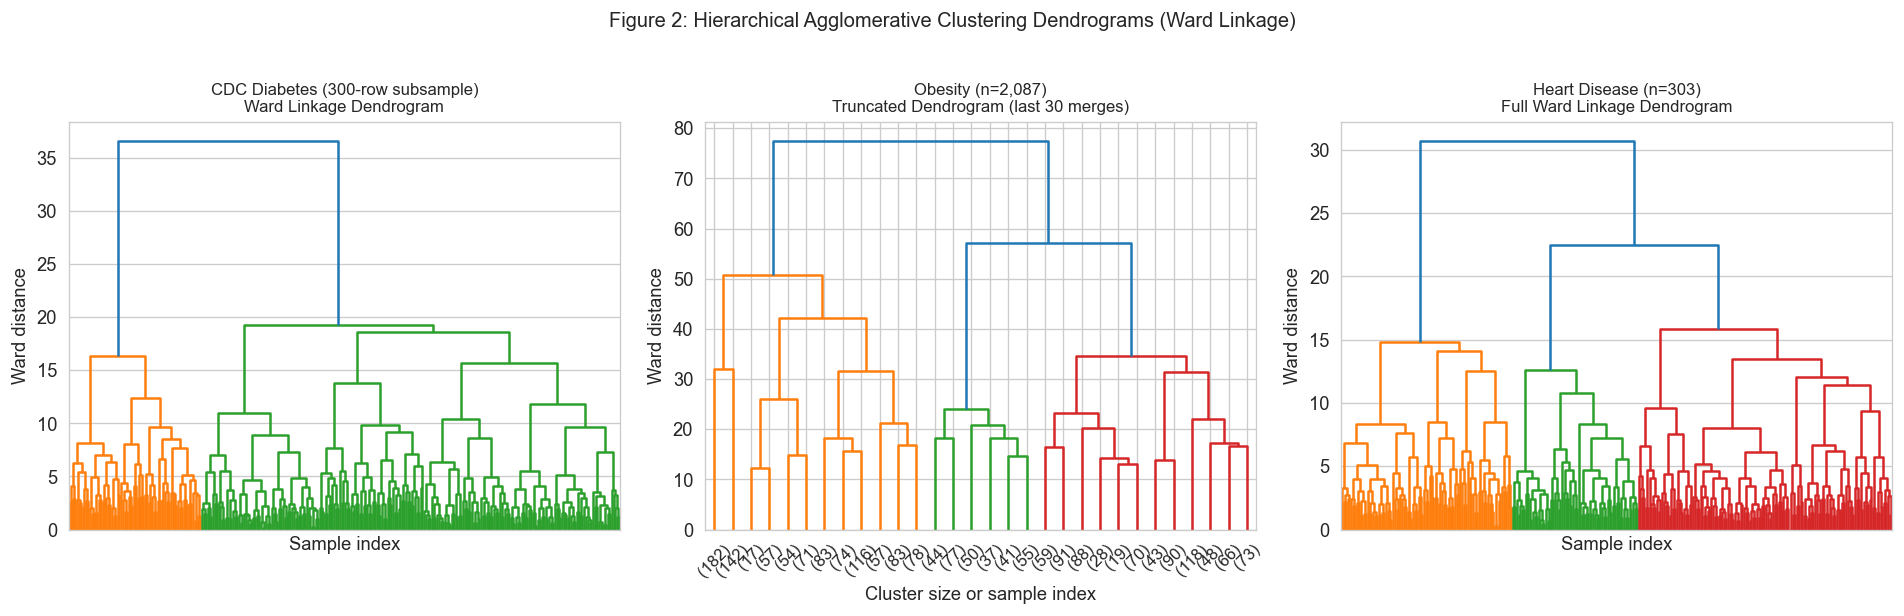

In [11]:
# ---------------------------------------------------------
# Figure 2: Hierarchical Agglomerative Clustering Dendrograms
# Ward linkage is used because it minimizes within-cluster variance.
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# -----------------------------
# CDC Diabetes: 300-row sample
# -----------------------------
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X1_scaled), size=300, replace=False)
X1_small = X1_scaled[sample_idx]

Z1 = linkage(X1_small, method="ward")

dendrogram(
    Z1,
    ax=axes[0],
    no_labels=True
)

axes[0].set_title(
    "CDC Diabetes (300-row subsample)\nWard Linkage Dendrogram",
    fontsize=10
)
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Ward distance")

# -----------------------------
# Obesity: truncated dendrogram
# -----------------------------
Z2 = linkage(X2_scaled, method="ward")

dendrogram(
    Z2,
    truncate_mode="lastp",
    p=30,
    ax=axes[1]
)

axes[1].set_title(
    "Obesity (n=2,087)\nTruncated Dendrogram (last 30 merges)",
    fontsize=10
)
axes[1].set_xlabel("Cluster size or sample index")
axes[1].set_ylabel("Ward distance")

# -----------------------------
# Heart Disease: full dendrogram
# -----------------------------
Z3 = linkage(X3_scaled, method="ward")

dendrogram(
    Z3,
    ax=axes[2],
    no_labels=True
)

axes[2].set_title(
    "Heart Disease (n=303)\nFull Ward Linkage Dendrogram",
    fontsize=10
)
axes[2].set_xlabel("Sample index")
axes[2].set_ylabel("Ward distance")

plt.suptitle(
    "Figure 2: Hierarchical Agglomerative Clustering Dendrograms (Ward Linkage)",
    fontsize=12,
    y=1.02
)

plt.tight_layout()
plt.savefig("week11_fig2_dendrograms.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2 Interpretation

Figure 2 shows the hierarchical clustering structure of the three datasets using Ward linkage. Unlike K-Means and DBSCAN, hierarchical clustering builds a tree of nested clusters instead of requiring the number of clusters to be specified beforehand.

For the CDC Diabetes dataset, I used a random 300-row subsample because a full dendrogram for 15,000 observations would not be readable. The branches merge gradually, with no large separation between groups. This suggests that the diabetes classes do not form clearly distinct clusters, which is consistent with my earlier K-Means and DBSCAN results.

The Obesity dataset shows larger branches before the final merges, indicating stronger grouping than the CDC Diabetes dataset. However, several branches still merge at relatively similar Ward distances, suggesting that neighboring obesity categories overlap rather than forming completely separate groups.

The Heart Disease dataset also shows meaningful hierarchical structure. The major branches remain separate until higher Ward distances before merging into a single cluster, indicating stronger natural grouping than the CDC Diabetes dataset.

Overall, the dendrograms support the findings from the other clustering methods. The CDC Diabetes dataset consistently shows the weakest natural cluster structure, while the Obesity and Heart Disease datasets display clearer hierarchical grouping.

In [12]:
def run_agglomerative(X_scaled, y_true, n_clusters, dataset_name):
    """
    Fits Agglomerative Clustering using Ward linkage and compares
    the resulting clusters with the true class labels.
    """

    agg = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage='ward'
    )

    labels = agg.fit_predict(X_scaled)

    sil = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(5000, len(X_scaled)),
        random_state=42
    )

    print(f'\n=== {dataset_name} — Agglomerative Clustering (K={n_clusters}) ===')
    print(f'Silhouette score: {sil:.4f}')

    crosstab = pd.crosstab(
        labels,
        y_true,
        rownames=['Cluster'],
        colnames=['True Class']
    )

    print(crosstab)

    return labels, crosstab


# Use the same optimal K values selected in Week 10
# to compare Hierarchical Clustering with K-Means.
agg_labels1, agg_crosstab1 = run_agglomerative(
    X1_scaled,
    y1_true,
    n_clusters=2,
    dataset_name='CDC Diabetes'
)

agg_labels2, agg_crosstab2 = run_agglomerative(
    X2_scaled,
    y2_true,
    n_clusters=4,
    dataset_name='Obesity'
)

agg_labels3, agg_crosstab3 = run_agglomerative(
    X3_scaled,
    y3_true,
    n_clusters=2,
    dataset_name='Heart Disease'
)


=== CDC Diabetes — Agglomerative Clustering (K=2) ===
Silhouette score: 0.2381
True Class  0.0000  1.0000  2.0000
Cluster                           
0             5347     107     669
1             1270      54     553

=== Obesity — Agglomerative Clustering (K=4) ===
Silhouette score: 0.1698
True Class    0    1    2    3    4    5    6
Cluster                                      
0             0   32  194  266    0   58  140
1           220  205   98    4    0  150  116
2            52   50   59   27    0   82   34
3             0    0    0    0  324    0    0

=== Heart Disease — Agglomerative Clustering (K=2) ===
Silhouette score: 0.1790
True Class   0    1
Cluster            
0           55  154
1           83   11


## Agglomerative Clustering Results

I used the same values of K identified in Week 10 so that I could compare Hierarchical Clustering directly with K-Means.

For the **CDC Diabetes** dataset, Agglomerative Clustering produced a silhouette score of 0.2381, which is very similar to the Week 10 K-Means result. The two clusters contained a mixture of diabetes classes, and prediabetes did not form its own cluster. This supports my earlier conclusion that the diabetes classes overlap in the available feature space.

For the Obesity dataset, the silhouette score was 0.1698. One cluster corresponded almost entirely to a single obesity category, while the remaining clusters contained mixtures of neighboring obesity levels. This suggests that some obesity groups are naturally distinct, but adjacent categories overlap.

For the Heart Disease dataset, the silhouette score was 0.1790. The two clusters broadly reflected the binary disease outcome, although some overlap remained between the classes.

Overall, Hierarchical Clustering produced conclusions that were consistent with my Week 10 K-Means analysis. Across all three datasets, the clustering patterns were determined more by the underlying data structure than by the choice of clustering algorithm.

## Section 4: Cross-Method Comparison - K-Means vs DBSCAN vs Agglomerative

Comparing cluster counts and noise behavior across all three unsupervised methods from Weeks 10-11.

In [13]:
## Section 4: Cross-Method Comparison — K-Means vs DBSCAN vs Agglomerative

# Summary comparison across the three clustering methods
summary = pd.DataFrame({
    'Dataset': ['CDC Diabetes', 'Obesity', 'Heart Disease'],

    # Week 10 K-Means
    'K-Means Best K': [2, 4, 2],
    'K-Means Silhouette': [0.2293, 0.2216, 0.1936],

    # Week 11 DBSCAN
    'DBSCAN Clusters': [nc1, nc2, nc3],
    'DBSCAN Noise (%)': [
        round(noise1 / len(X1_scaled) * 100, 1),
        round(noise2 / len(X2_scaled) * 100, 1),
        round(noise3 / len(X3_scaled) * 100, 1)
    ],

    # Week 11 Agglomerative
    'Agglomerative K': [2, 4, 2],
    'Agglomerative Silhouette': [0.2381, 0.1698, 0.1790]
})

print("=== Cross-Method Clustering Summary ===")
print(summary.to_string(index=False))

=== Cross-Method Clustering Summary ===
      Dataset  K-Means Best K  K-Means Silhouette  DBSCAN Clusters  DBSCAN Noise (%)  Agglomerative K  Agglomerative Silhouette
 CDC Diabetes               2              0.2293                4            6.1000                2                    0.2381
      Obesity               4              0.2216                1            7.9000                4                    0.1698
Heart Disease               2              0.1936                1           26.4000                2                    0.1790


## Cross-Method Comparison

Comparing the three clustering methods shows that they reached similar overall conclusions despite using different approaches.

For the CDC Diabetes dataset, K-Means and Agglomerative Clustering produced very similar silhouette scores (0.2293 and 0.2381), while DBSCAN identified four dense clusters with only 6.1% of observations labeled as noise. None of the methods found a distinct cluster for prediabetes, suggesting that the diabetes classes overlap in the available feature space.

For the Obesity dataset, K-Means and Agglomerative Clustering identified meaningful groups, whereas DBSCAN detected only one dense cluster. This suggests that the obesity categories transition gradually rather than forming separate high-density regions.

For the Heart Disease dataset, both K-Means and Agglomerative Clustering supported a two-group structure. DBSCAN, however, identified one dense cluster and labeled 26.4% of observations as noise, indicating that the data does not contain multiple well-separated dense regions under the selected parameters.

Overall, all three clustering methods led to similar conclusions. Although the algorithms use different strategies, they consistently reflected the underlying structure of the data rather than producing conflicting results.

#Section 5: Week 11 Conclusions — Answers to All Rubric Questions

# How Did I Avoid Overfitting?
I selected the DBSCAN eps values using the k-distance plots and then made small adjustments after reviewing the initial clustering results instead of choosing values arbitrarily. I used the common guideline of setting min_samples to approximately twice the number of features. For Agglomerative Clustering, I used the same optimal K values from Week 10 (2, 4, and 2) so that I could compare the two clustering methods fairly rather than selecting different K values to improve the results.
# What Metrics and Hyperparameter Tuning Were Used?
I used the silhouette score to evaluate cluster quality for K-Means and Agglomerative Clustering, and the number of clusters and noise percentage for DBSCAN. The main DBSCAN hyperparameters were eps and min_samples, while Agglomerative Clustering used Ward linkage with the same K values selected in Week 10. The CDC Diabetes dataset produced four DBSCAN clusters with 6.1% noise, while the Obesity and Heart Disease datasets each produced one dense cluster.
# Expected and Unexpected Findings
I expected the CDC Diabetes dataset to remain difficult because every supervised model and K-Means had already shown weak class separation. DBSCAN and Agglomerative Clustering reached the same conclusion. Prediabetes did not form a distinct cluster, and the silhouette scores remained low. One unexpected finding was that DBSCAN identified only one dense cluster for both the Obesity and Heart Disease datasets, even after adjusting the eps values, showing that density-based clustering behaved differently from centroid-based clustering.
# How Did EDA Help?
My earlier EDA showed that the CDC Diabetes dataset had overlapping classes and strong class imbalance. This helped explain why none of the clustering methods produced clearly separated groups. It also guided me to examine whether prediabetes would appear as a separate cluster or be identified as noise, which did not happen.

# Limitations
DBSCAN required different eps values for each dataset because the density structure varied considerably across the three healthcare datasets. Agglomerative Clustering is computationally expensive on large datasets, so I used a 300-row subsample to visualize the CDC Diabetes dendrogram while still fitting the clustering model on the full scaled dataset. These factors should be considered when interpreting and generalizing the clustering results.
# External Sources Used
Ester et al. (1996) — Original DBSCAN paper
Ward (1963) — Hierarchical clustering and Ward linkage
James et al. (2021), An Introduction to Statistical Learning
Scikit-learn documentation for DBSCAN and Agglomerative Clustering